# Finding an Exoplanet in TESS Data
**Esteban Flores** · UC Merced, Data Science & Computing (Physics emphasis)

When a planet passes in front of its star, the star's brightness dips a little. How deep the dip is tells us how big the planet is:

$$\text{depth} \approx \left(\frac{R_p}{R_\star}\right)^2 \quad\Longrightarrow\quad R_p = R_\star\sqrt{\text{depth}}$$

This notebook follows the OSEMN steps:

1. **Obtain**: download a TESS light curve (star brightness over time) from NASA.
2. **Scrub**: remove missing values and outliers, and flatten out the star's own slow brightness changes.
3. **Explore**: plot the light curve and look for dips.
4. **Model**: search for repeating dips with a Box Least Squares (BLS) periodogram, then estimate the dip depth.
5. **iNterpret**: turn depth into planet radius, with a bootstrap uncertainty, and compare to NASA's published value.

> **Test mode:** set `USE_SIMULATED = True` to run the whole notebook on a fake light curve with a planet of *known* size planted in it. If the pipeline recovers the planted values, you know the code works before you trust it on real data.

In [1]:
USE_SIMULATED = False      # True = test on a fake planet with known answers
TARGET = "WASP-18"         # star name (host of WASP-18 b)
PLANET = "WASP-18 b"       # planet name as NASA's archive spells it
SEED = 42

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.timeseries import BoxLeastSquares

rng = np.random.default_rng(SEED)
R_SUN_IN_R_EARTH = 109.1   # 1 solar radius = 109.1 Earth radii
plt.rcParams["figure.figsize"] = (10, 3.5)

## 1. Obtain

/Users/estebanflores/exoplanet-transits/.venv/lib/python3.14/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


SearchResult containing 10 data products.

 #      mission     year author exptime target_name distance
                                   s                 arcsec 
--- --------------- ---- ------ ------- ----------- --------
  0  TESS Sector 02 2018   SPOC     120   100100827      0.0
  1  TESS Sector 03 2018   SPOC     120   100100827      0.0
  2  TESS Sector 29 2020   SPOC     120   100100827      0.0
  3  TESS Sector 30 2020   SPOC     120   100100827      0.0
  4  TESS Sector 69 2023   SPOC     120   100100827      0.0
  5  TESS Sector 96 2025   SPOC     120   100100827      0.0
  6 TESS Sector 103 2026   SPOC     120   100100827      0.0
  7 TESS Sector 104 2026   SPOC     120   100100827      0.0
  8 TESS Sector 105 2026   SPOC     120   100100827      0.0
  9 TESS Sector 106 2026   SPOC     120   100100827      0.0


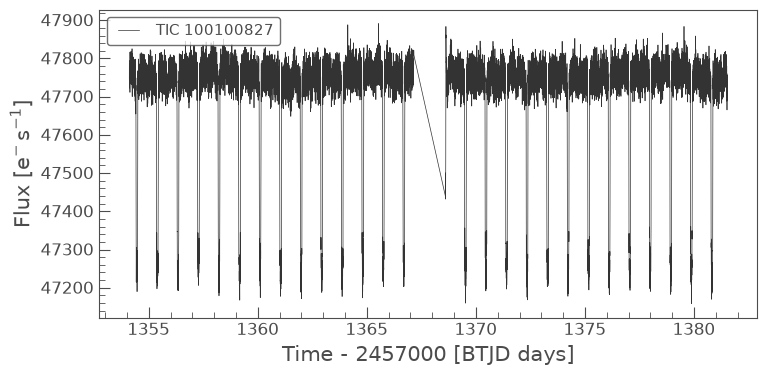

In [2]:
if USE_SIMULATED:
    # Fake light curve: 27 days at 2-minute cadence, like one TESS sector
    time = np.arange(0, 27, 2 / 60 / 24)
    time = time[(time < 13) | (time > 14.2)]          # TESS has a data gap mid-sector
    TRUE = dict(period=0.94145, t0=0.30, duration=0.09, depth=0.0095)
    phase = ((time - TRUE["t0"] + 0.5 * TRUE["period"]) % TRUE["period"]) - 0.5 * TRUE["period"]
    flux = np.ones_like(time)
    flux[np.abs(phase) < TRUE["duration"] / 2] -= TRUE["depth"]
    flux_err = np.full_like(time, 1e-3)
    flux = flux + rng.normal(0, 1e-3, time.size)
    print(f"Simulated {time.size:,} points. Planted: {TRUE}")
else:
    import lightkurve as lk
    results = lk.search_lightcurve(TARGET, mission="TESS", author="SPOC", exptime=120)
    print(results)                      # every sector available for this star
    lc_raw = results[0].download()      # start with the first sector
    lc_raw.plot();

## 2. Scrub
Real TESS data has missing values, cosmic-ray spikes, and slow brightness drifts from the star and the spacecraft. `flatten()` fits a smooth curve and divides it out, leaving the short transit dips behind. Outlier removal only clips *upward* spikes (`sigma_lower` is huge), so the transits themselves are never thrown away.

In [3]:
if not USE_SIMULATED:
    lc = (lc_raw.remove_nans()
                .normalize()
                .flatten(window_length=901)                 # ~30 hours at 2-min cadence
                .remove_outliers(sigma_upper=4, sigma_lower=50))
    time, flux, flux_err = lc.time.value, lc.flux.value, lc.flux_err.value
    print(f"{len(lc_raw):,} raw points -> {time.size:,} after cleaning")

ok = np.isfinite(time) & np.isfinite(flux) & np.isfinite(flux_err)
time, flux, flux_err = time[ok], flux[ok], flux_err[ok]

18,299 raw points -> 18,299 after cleaning


## 3. Explore

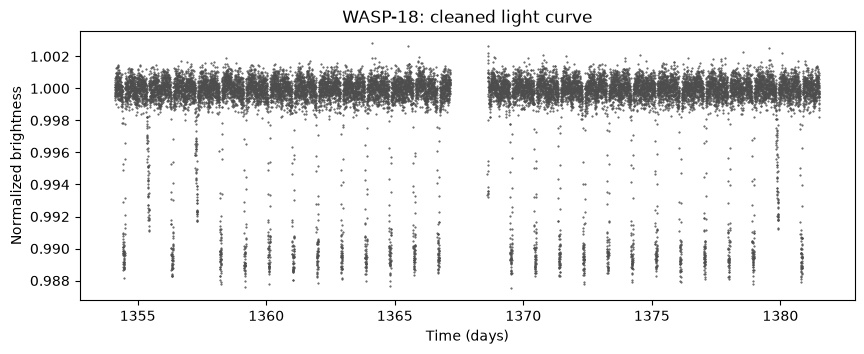

Point-to-point scatter: 2759 ppm


In [4]:
fig, ax = plt.subplots()
ax.plot(time, flux, ".", ms=1, color="0.3")
ax.set(xlabel="Time (days)", ylabel="Normalized brightness", title=f"{TARGET}: cleaned light curve")
plt.show()
print(f"Point-to-point scatter: {np.std(flux) * 1e6:.0f} ppm")

## 4. Model: Box Least Squares search
BLS slides a box-shaped dip across many trial periods and scores how well each one fits. The highest peak in the periodogram is the most likely orbital period.

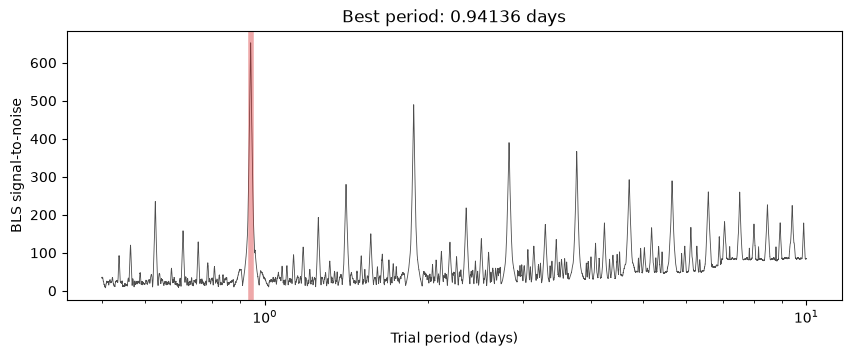

Period   = 0.94136 d
T0       = 1354.4595 d
Duration = 1.92 h


In [5]:
bls = BoxLeastSquares(time, flux, dy=flux_err)
periods = np.exp(np.linspace(np.log(0.5), np.log(10), 30000))   # 0.5 to 10 days
durations = [0.04, 0.06, 0.08, 0.10, 0.12, 0.16]                   # days
pg = bls.power(periods, durations, objective="snr")

best = np.argmax(pg.power)
period, t0, duration = pg.period[best], pg.transit_time[best], pg.duration[best]

fig, ax = plt.subplots()
ax.plot(pg.period, pg.power, lw=0.6, color="0.3")
ax.axvline(period, color="tab:red", alpha=0.4, lw=4)
ax.set(xscale="log", xlabel="Trial period (days)", ylabel="BLS signal-to-noise",
       title=f"Best period: {period:.5f} days")
plt.show()
print(f"Period   = {period:.5f} d\nT0       = {t0:.4f} d\nDuration = {duration * 24:.2f} h")

### Fold the light curve
Folding stacks every orbit on top of the others, so all the transits line up at phase 0. If the period is right, you'll see one clean dip.

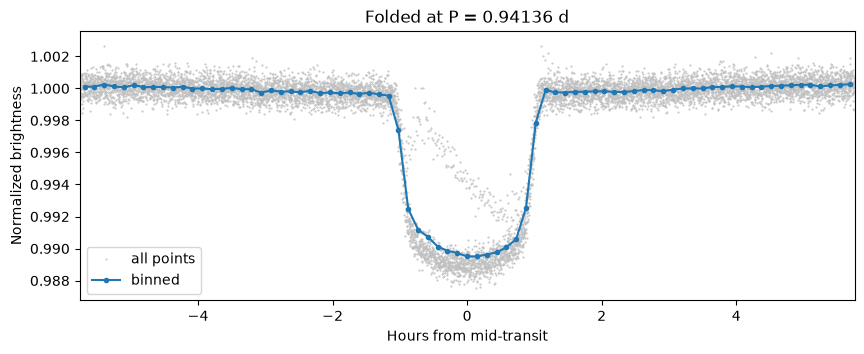

In [6]:
phase = ((time - t0 + 0.5 * period) % period) - 0.5 * period      # days from mid-transit
in_tr = np.abs(phase) < 0.25 * duration     # central half of transit (avoids ingress/egress)
out_tr = np.abs(phase) > 1.0 * duration     # well outside transit

# binned curve for readability
bins = np.linspace(-3 * duration, 3 * duration, 80)
idx = np.digitize(phase, bins)
bx = [phase[idx == i].mean() for i in range(1, len(bins)) if np.any(idx == i)]
by = [flux[idx == i].mean() for i in range(1, len(bins)) if np.any(idx == i)]

fig, ax = plt.subplots()
ax.plot(phase * 24, flux, ".", ms=1, color="0.75", label="all points")
ax.plot(np.array(bx) * 24, by, "o-", ms=3, color="tab:blue", label="binned")
ax.set(xlim=(-3 * duration * 24, 3 * duration * 24), xlabel="Hours from mid-transit",
       ylabel="Normalized brightness", title=f"Folded at P = {period:.5f} d")
ax.legend(); plt.show()

## 5. iNterpret: depth to radius, with uncertainty
**Depth** is the mean brightness outside transit minus the mean inside. To get an uncertainty, I **bootstrap**: resample the in-transit and out-of-transit points with replacement 5,000 times and recompute the depth each time.

The planet radius also depends on the **star's radius**, which has its own uncertainty. So each bootstrap draw is paired with a random draw of $R_\star$ (Monte Carlo error propagation). The 2.5th and 97.5th percentiles give a 95% interval.

In [7]:
def get_archive(planet):
    # Published values from the NASA Exoplanet Archive (Planetary Systems Composite table)
    q = ("select pl_name,pl_orbper,pl_rade,pl_radeerr1,pl_radeerr2,st_rad,st_raderr1,st_raderr2 "
         f"from pscomppars where pl_name='{planet}'")
    url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync?format=csv&query=" + q.replace(" ", "+")
    return pd.read_csv(url).iloc[0]

if USE_SIMULATED:
    star_r, star_r_err = 1.23, 0.05
    ref = pd.Series(dict(pl_orbper=TRUE["period"],
                         pl_rade=np.sqrt(TRUE["depth"]) * star_r * R_SUN_IN_R_EARTH))
else:
    ref = get_archive(PLANET)
    star_r = ref["st_rad"]
    star_r_err = np.nanmean([abs(ref["st_raderr1"]), abs(ref["st_raderr2"])])
print(f"Star radius: {star_r:.3f} ± {star_r_err:.3f} R_sun")

Star radius: 1.319 ± 0.061 R_sun


In [8]:
f_in, f_out = flux[in_tr], flux[out_tr]
depth = f_out.mean() - f_in.mean()

B = 5000
boot_depth = np.empty(B)
for b in range(B):
    boot_depth[b] = (rng.choice(f_out, f_out.size).mean()
                     - rng.choice(f_in, f_in.size).mean())

boot_rstar = rng.normal(star_r, star_r_err, B)
boot_rp = np.sqrt(np.clip(boot_depth, 0, None)) * boot_rstar * R_SUN_IN_R_EARTH

rp = np.sqrt(depth) * star_r * R_SUN_IN_R_EARTH
lo, hi = np.percentile(boot_rp, [2.5, 97.5])
d_lo, d_hi = np.percentile(boot_depth, [2.5, 97.5])

print(f"Depth  = {depth * 1e6:,.0f} ppm   (95% CI {d_lo * 1e6:,.0f} to {d_hi * 1e6:,.0f})")
print(f"Radius = {rp:.2f} R_earth  (95% CI {lo:.2f} to {hi:.2f})  = {rp / 11.21:.2f} R_jupiter")

Depth  = 10,309 ppm   (95% CI 10,176 to 10,436)
Radius = 14.61 R_earth  (95% CI 13.27 to 15.95)  = 1.30 R_jupiter


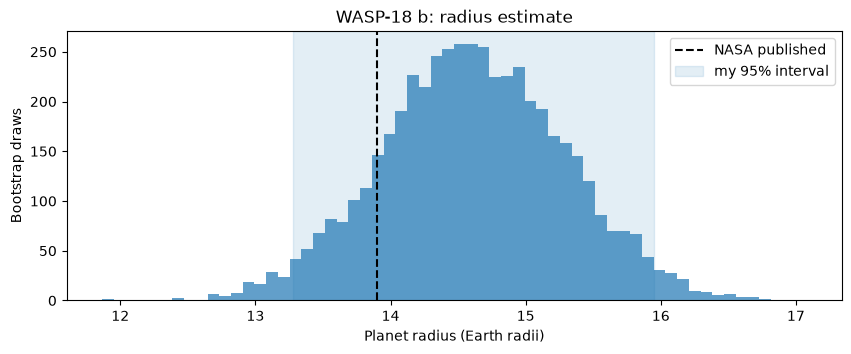

Radius differs from reference by +5.1%


,My estimate,Reference
Period (days),0.94136,0.94145
Radius (Earth radii),14.61 (13.27 to 15.95),13.90


In [9]:
fig, ax = plt.subplots()
ax.hist(boot_rp, bins=60, color="tab:blue", alpha=0.7)
ax.axvline(ref["pl_rade"], color="k", ls="--", label="NASA published" if not USE_SIMULATED else "planted (true)")
ax.axvspan(lo, hi, color="tab:blue", alpha=0.12, label="my 95% interval")
ax.set(xlabel="Planet radius (Earth radii)", ylabel="Bootstrap draws", title=f"{PLANET}: radius estimate")
ax.legend(); plt.show()

summary = pd.DataFrame({
    "My estimate": [f"{period:.5f}", f"{rp:.2f} ({lo:.2f} to {hi:.2f})"],
    "Reference":   [f"{ref['pl_orbper']:.5f}", f"{ref['pl_rade']:.2f}"],
}, index=["Period (days)", "Radius (Earth radii)"])
pct_off = 100 * (rp - ref["pl_rade"]) / ref["pl_rade"]
print(f"Radius differs from reference by {pct_off:+.1f}%")
summary

## What I found
Using one month of NASA TESS data for the star WASP-18, I found that its planet, WASP-18 b, orbits every 0.94136 days (about 22.6 hours). This matches NASA's published value of 0.94145 days to within 0.01%.

From the depth of the transit dip, I estimated the planet's radius as 14.61 Earth radii (95% interval: 13.27 to 15.95), about 1.3 times the size of Jupiter. NASA's published value is 13.90, so my estimate is 5.1% high, but NASA's value falls inside my 95% interval.

The likely reason for the overestimate is limb darkening: stars look brighter at the center than at the edges. I measured the dip depth near mid-transit, where the planet blocks the brightest part of the star, so my simple box model makes the planet look slightly bigger. A physical transit model that accounts for limb darkening would correct this.

## Next steps
- Run on several TESS sectors and check that the period stays stable.
- Replace the box with a physical transit model (`batman`) and fit it with MCMC (`emcee`) to get a true Bayesian posterior for the radius.
- Try a harder target: a smaller planet with a shallower dip.